In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [6]:
d=pd.read_csv(r"C:\Users\sivas\Downloads\Red.csv")
d

,Name,Country,Region,Winery,Rating,NumberOfRatings,Price,Year
0,Pomerol 2011,France,Pomerol,Château La Providence,4.2,100,95.00,2011
1,Lirac 2017,France,Lirac,Château Mont-Redon,4.3,100,15.50,2017
2,Erta e China Rosso di Toscana 2015,Italy,Toscana,Renzo Masi,3.9,100,7.45,2015
3,Bardolino 2019,Italy,Bardolino,Cavalchina,3.5,100,8.72,2019
4,Ried Scheibner Pinot Noir 2016,Austria,Carnuntum,Markowitsch,3.9,100,29.15,2016
...,...,...,...,...,...,...,...,...
8661,6th Sense Syrah 2016,United States,Lodi,Michael David Winery,3.8,994,16.47,2016
8662,Botrosecco Maremma Toscana 2016,Italy,Maremma Toscana,Le Mortelle,4.0,995,20.09,2016
8663,Haut-Médoc 2010,France,Haut-Médoc,Château Cambon La Pelouse,3.7,996,23.95,2010
8664,Shiraz 2019,Australia,South Eastern Australia,Yellow Tail,3.5,998,6.21,2019


In [9]:
d.columns

Index(['Name', 'Country', 'Region', 'Winery', 'Rating', 'NumberOfRatings',
       'Price', 'Year'],
      dtype='object')

In [11]:
d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8666 entries, 0 to 8665
Data columns (total 8 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Name             8666 non-null   object 
 1   Country          8666 non-null   object 
 2   Region           8666 non-null   object 
 3   Winery           8666 non-null   object 
 4   Rating           8666 non-null   float64
 5   NumberOfRatings  8666 non-null   int64  
 6   Price            8666 non-null   float64
 7   Year             8666 non-null   object 
dtypes: float64(2), int64(1), object(5)
memory usage: 541.8+ KB


In [13]:
np.mean(d["Rating"])

3.8903415647357487

In [14]:
d["NumberOfRatings"].unique()

array([ 100, 1000, 1001, ...,  996,  998,  999], dtype=int64)

In [16]:
d.columns[d.isnull().any()]

Index([], dtype='object')

In [17]:
nd=d.select_dtypes(["float64","int64"])
nd

,Rating,NumberOfRatings,Price
0,4.2,100,95.00
1,4.3,100,15.50
2,3.9,100,7.45
3,3.5,100,8.72
4,3.9,100,29.15
...,...,...,...
8661,3.8,994,16.47
8662,4.0,995,20.09
8663,3.7,996,23.95
8664,3.5,998,6.21


In [18]:
nd.kurt()

Rating               0.002640
NumberOfRatings    126.933983
Price              353.421256
dtype: float64

In [19]:
nd.corr()

,Rating,NumberOfRatings,Price
Rating,1.000000,0.075216,0.451060
NumberOfRatings,0.075216,1.000000,0.006407
Price,0.451060,0.006407,1.000000


In [20]:
from sklearn.model_selection import train_test_split

In [21]:
x=nd[["Rating","NumberOfRatings"]]
y=nd["Price"]

In [22]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)
x_train


,Rating,NumberOfRatings
8577,3.8,97
2988,4.0,253
5241,3.7,42
107,4.1,103
7181,4.3,672
...,...,...
5734,4.3,473
5191,4.1,42
5390,3.6,44
860,3.5,128


In [23]:
from sklearn.linear_model import LinearRegression

In [24]:
from sklearn.metrics import r2_score

In [25]:
lr=LinearRegression()
lr.fit(x_train,y_train)

LinearRegression()

In [26]:
y_pred=lr.predict(x_test)
y_pred

array([-22.60614686,   3.46746835,   2.48433441, ...,  28.99650445,
        28.86638379,  28.97722732])

In [27]:
lr.coef_

array([ 1.27295782e+02, -2.40964201e-03])

In [28]:
lr.intercept_

-454.66481817561737

In [29]:
r2_score(y_test,y_pred)

0.2719146414373972

In [30]:
i=[[4.0,90]]
lr.predict((i))

c:\Users\sivas\anaconda3\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([54.30144386])

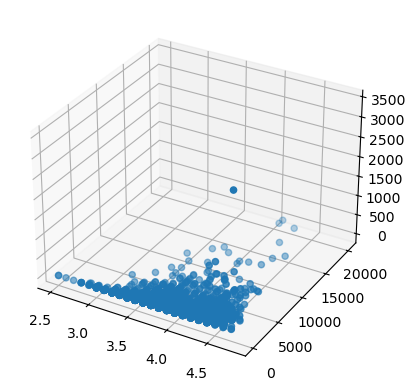

In [32]:
fig=plt.figure()
ax=fig.add_subplot(111,projection="3d")
ax.scatter(x["Rating"],x["NumberOfRatings"],y)
plt.show()